In [ ]:
! pip install pandas
! pip install numpy
! pip install matplotlib
! pip install seaborn

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Read in the dataset
df = pd.read_csv('./car_sales_data.csv')
print(df.head())

         Date      Salesperson   Customer Name Car Make  Car Model  Car Year  \
0  2022-08-01  Monica Moore MD     Mary Butler   Nissan     Altima    2018.0   
1  2023-03-15     Roberto Rose  Richard Pierce   Nissan      F-150    2016.0   
2  2023-04-29     Ashley Ramos    Sandra Moore     Ford      Civic    2016.0   
3  2022-09-04   Patrick Harris    Johnny Scott     Ford     Altima    2013.0   
4  2022-06-16       Eric Lopez   Vanessa Jones    Honda  Silverado    2022.0   

   Sale Price  Commission Rate  Commission Earned  
0     15983.0         0.070495            1126.73  
1     38474.0         0.134439            5172.40  
2     33340.0         0.114536            3818.63  
3     41937.0         0.092191            3866.20  
4     20256.0         0.113490            2298.85  


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1458981 entries, 0 to 1458980
Data columns (total 9 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Date               1458981 non-null  object 
 1   Salesperson        1458980 non-null  object 
 2   Customer Name      1458980 non-null  object 
 3   Car Make           1458980 non-null  object 
 4   Car Model          1458980 non-null  object 
 5   Car Year           1458980 non-null  float64
 6   Sale Price         1458980 non-null  float64
 7   Commission Rate    1458980 non-null  float64
 8   Commission Earned  1458980 non-null  float64
dtypes: float64(4), object(5)
memory usage: 100.2+ MB
None


In [ ]:
print(df.isnull().sum())

In [8]:
df = df.dropna(subset=["Sale Price", "Car Model"])

In [ ]:
print(df.isnull().sum())

In [14]:
print(df["Car Make"].unique())
print(df["Sale Price"].unique())

['Nissan' 'Ford' 'Honda' 'Toyota' 'Chevrolet']
[15983. 38474. 33340. ... 14499. 18868. 19538.]


In [12]:
#df["Car Model"] = df["Car Model"].replace({
#    "Altima": "Yamaha",
#    "F-150": "F-MEGA"
#})

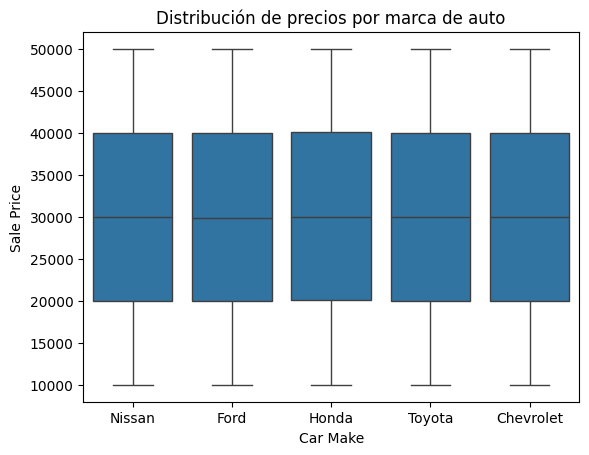

In [15]:
sns.boxplot(x="Car Make", y="Sale Price", data=df)
plt.title("Distribución de precios por marca de auto")
plt.show()

In [18]:
q_low = df["Sale Price"].quantile(0.01)
q_high = df["Sale Price"].quantile(0.99)
df = df[(df["Sale Price"] >= q_low) & (df["Sale Price"] <= q_high)]

In [ ]:
print("Tamaño del dataset limpio:", df.shape)

In [12]:
print("\nEstadísticos descriptivos de variables numéricas:")
print(df[["Sale Price", "Commission Earned"]].describe())


Estadísticos descriptivos de variables numéricas:
         Sale Price  Commission Earned
count  1.458980e+06       1.458980e+06
mean   3.001313e+04       3.001200e+03
std    1.154187e+04       1.481279e+03
min    1.000000e+04       5.013400e+02
25%    2.002400e+04       1.822160e+03
50%    3.000300e+04       2.742180e+03
75%    4.002100e+04       3.979360e+03
max    5.000000e+04       7.494530e+03


In [16]:
print("\nFrecuencia de los modelos más comunes:")
print(df["Car Model"].value_counts().head(10))

print("\nFrecuencia de las marcas más comunes:")
print(df["Car Make"].value_counts())


Frecuencia de los modelos más comunes:
Car Model
Silverado    292626
Civic        291988
Corolla      291722
F-150        291421
Altima       291223
Name: count, dtype: int64

Frecuencia de las marcas más comunes:
Car Make
Honda        292212
Ford         292063
Chevrolet    292055
Toyota       291493
Nissan       291157
Name: count, dtype: int64


In [20]:
print("\nRango de precios:")
print("Mínimo:", df["Sale Price"].min())
print("Máximo:", df["Sale Price"].max())

print("\nRango de anios vendidos:")
print("Mínimo:", df["Car Year"].min())
print("Máximo:", df["Car Year"].max())


Rango de precios:
Mínimo: 10000.0
Máximo: 50000.0

Rango de anios vendidos:
Mínimo: 2010.0
Máximo: 2022.0


In [23]:
Q1 = df["Sale Price"].quantile(0.25)
Q3 = df["Sale Price"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df["Sale Price"] < Q1 - 1.5*IQR) | (df["Sale Price"] > Q3 + 1.5*IQR)]
print("\nCantidad de outliers en Precio:", outliers.shape[0])


Cantidad de outliers en Precio: 0
